# **Superstore Sales Analysis for Business Intelligence**

### **Import Libraries**

In [2]:
import numpy as np              # for numerical and mathematical operations
import pandas as pd             # for data loading and manipulation
import matplotlib.pyplot as plt # for basic data visualization
import seaborn as sns           # for advanced statistical plots

import warnings                 # Import warnings module to manage warning messages
warnings.filterwarnings("ignore", category=UserWarning) # Ignore specific UserWarning messages

### **Set visualization style**

In [3]:
plt.style.use('seaborn-v0_8-darkgrid')   # graphs ka background zyada clear (looks)
sns.set_palette("husl")                  # graph ke colors & category ko alag–alag bright color

### **Import csv files**

In [9]:
df = pd.read_csv(r"c:\Users\dearh\Downloads\Mind Fuc88r\Project-Build-Superstore_Sales_Analysis\Cleaned_Superstore.csv")  #load data from csv file a dataframe

### **Data Size & Sample data**

In [10]:
print("\n🧮 Size of Data:")
print(df.size)                  # show number of cells in the dataset

print("\n🧮 Shape of Data:")
print(df.shape)                  # show number of rows and columns

print("\n🔍 First 5 rows:")          
display(df.head(5))                   # display first 5 rows of the dataset


🧮 Size of Data:
209874

🧮 Shape of Data:
(9994, 21)

🔍 First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### **Data Information**

In [11]:
print("\n📋 Column Information:")
print(df.info())    # Shows column names, data types, and missing values


📋 Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null 

In [12]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

### **Basic Statistics**

In [13]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## **DATA CLEANING AND PREPROCESSING**


### **Check for missing values or Abnormal Values**

In [14]:
print("🔎 Missing Values:")

missing = df.isnull().sum()       # count missing values in each column
print(missing)       # show only columns that have missing data

🔎 Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [15]:
print("🔎 Duplicated Values:")
print(df.duplicated().sum())      # count duplicated rows in the dataset

🔎 Duplicated Values:
0



### **Convert date column**

In [16]:
# Convert 'Order Date' column to datetime format (invalid values become NaT)
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')


#### **Convert 'Postal Code' to string**

In [17]:
df['Postal Code'] = df['Postal Code'].astype(str)

#### **🧮 Save cleaned data**

In [18]:
df.to_csv('Cleaned_Superstore.csv', index=False, encoding='utf-8')

## **CHECKING CLEANED DATASET**

In [19]:
df.head(20)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
6,7,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656
7,8,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
8,9,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825
9,10,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700


### **Exploratory Data Analysis (Python):**

#### **1. Total sales & profit by product category and region**

In [20]:
summary = df.groupby(['Category', 'Region'])[['Sales', 'Profit']].sum()
print(summary)

                               Sales      Profit
Category        Region                          
Furniture       Central  163797.1638  -2871.0494
                East     208291.2040   3046.1658
                South    117298.6840   6771.2061
                West     252612.7435  11504.9503
Office Supplies Central  167026.4150   8879.9799
                East     205516.0550  41014.5791
                South    125651.3130  19986.3928
                West     220853.2490  52609.8490
Technology      Central  170416.3120  33697.4320
                East     264973.9810  47462.0351
                South    148771.9080  19991.8314
                West     251991.8320  44303.6496


#### **2.Identify top customers by revenue**

In [21]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_customers)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


#### **3.Monthly sales trends and seasonality**

In [22]:
df['Year-Month'] = df['Order Date'].dt.to_period('M').astype(str)
monthly_sales = df.groupby('Year-Month')['Sales'].sum().reset_index()
print(monthly_sales)

   Year-Month        Sales
0     2014-01   14236.8950
1     2014-02    4519.8920
2     2014-03   55691.0090
3     2014-04   28295.3450
4     2014-05   23648.2870
5     2014-06   34595.1276
6     2014-07   33946.3930
7     2014-08   27909.4685
8     2014-09   81777.3508
9     2014-10   31453.3930
10    2014-11   78628.7167
11    2014-12   69545.6205
12    2015-01   18174.0756
13    2015-02   11951.4110
14    2015-03   38726.2520
15    2015-04   34195.2085
16    2015-05   30131.6865
17    2015-06   24797.2920
18    2015-07   28765.3250
19    2015-08   36898.3322
20    2015-09   64595.9180
21    2015-10   31404.9235
22    2015-11   75972.5635
23    2015-12   74919.5212
24    2016-01   18542.4910
25    2016-02   22978.8150
26    2016-03   51715.8750
27    2016-04   38750.0390
28    2016-05   56987.7280
29    2016-06   40344.5340
30    2016-07   39261.9630
31    2016-08   31115.3743
32    2016-09   73410.0249
33    2016-10   59687.7450
34    2016-11   79411.9658
35    2016-12   96999.0430
3

### **Data Visualization**

#### **1.Bar Chart – Top Products by Sales**

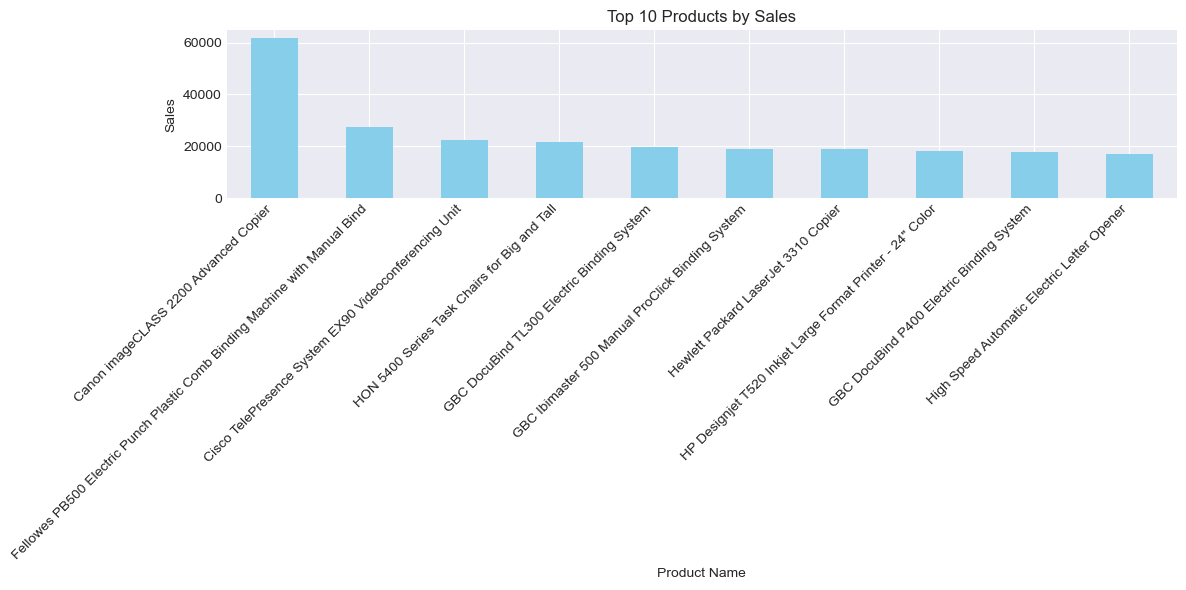

In [23]:
import matplotlib.pyplot as plt

# Top 10 products by sales
top_products = df.groupby('Product Name')['Sales'].sum().nlargest(10)

# Bar chart
plt.figure(figsize=(12,6))
top_products.plot(kind='bar', color='skyblue')
plt.title('Top 10 Products by Sales')
plt.ylabel('Sales')
plt.xlabel('Product Name')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### **2.Line Chart – Monthly Sales Trend**

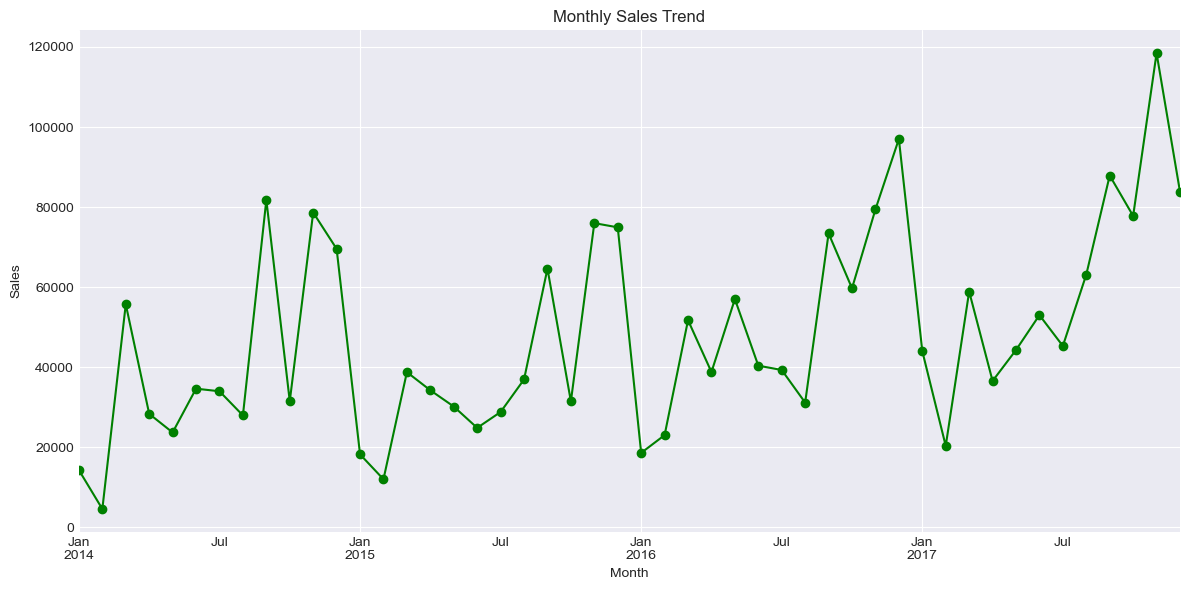

In [24]:
# Convert 'Order Date' to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Group by month
monthly_sales = df.resample('ME', on='Order Date')['Sales'].sum()

# Line chart
plt.figure(figsize=(12,6))
monthly_sales.plot(kind='line', marker='o', color='green')
plt.title('Monthly Sales Trend')
plt.ylabel('Sales')
plt.xlabel('Month')
plt.grid(True)
plt.tight_layout()
plt.show()

#### **3.Heatmap – Sales Distribution by State and Category**

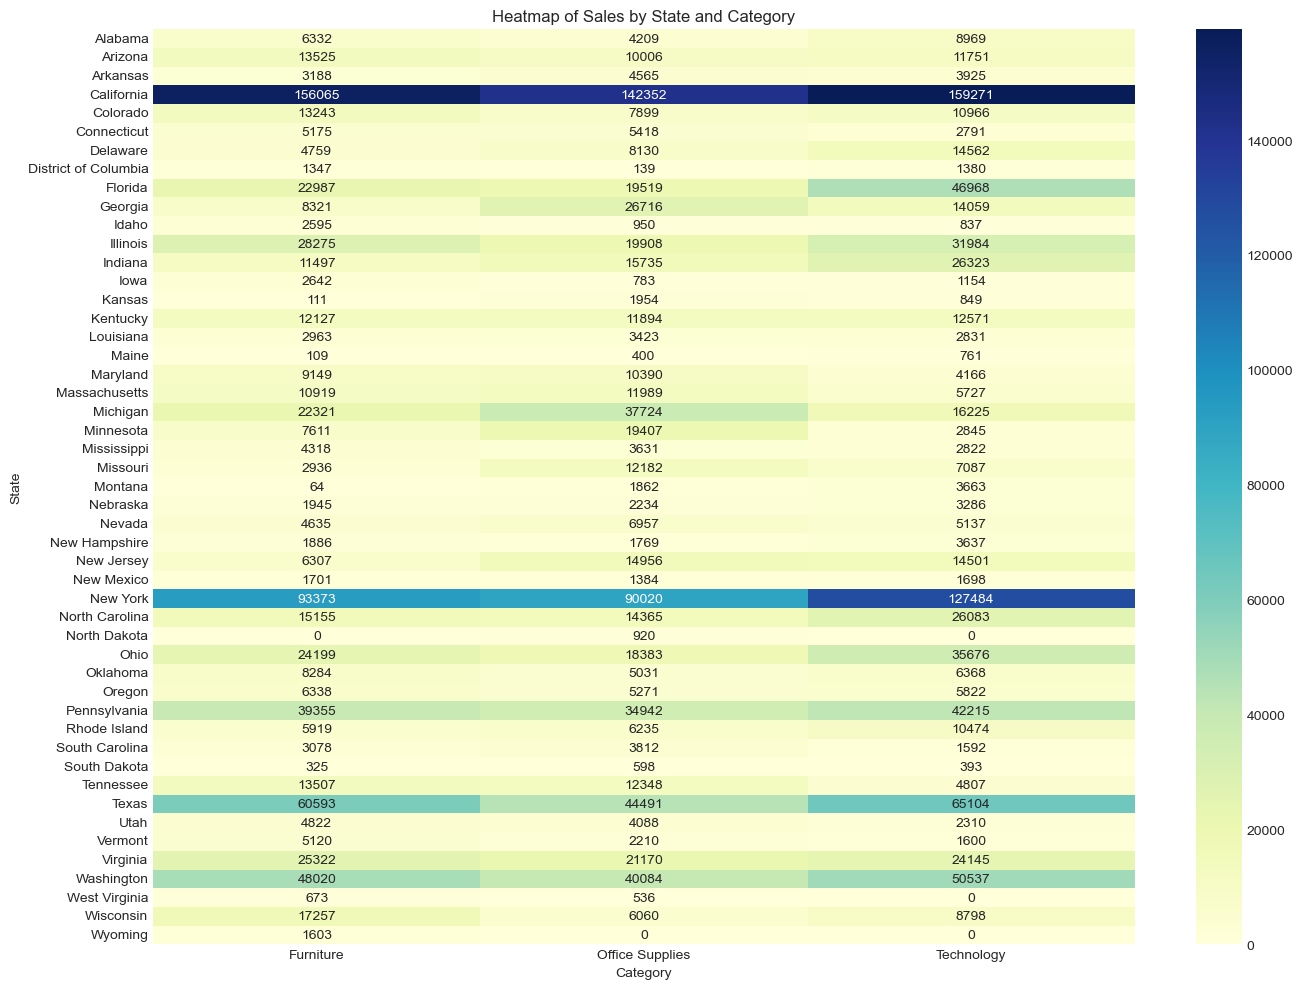

In [25]:
import seaborn as sns

# Pivot table for heatmap
heatmap_data = df.pivot_table(values='Sales', index='State', columns='Category', aggfunc='sum').fillna(0)

# Heatmap
plt.figure(figsize=(14,10))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Heatmap of Sales by State and Category')
plt.ylabel('State')
plt.xlabel('Category')
plt.tight_layout()
plt.show()

#### **4.Sales Distribution by Region (Pie Chart)**

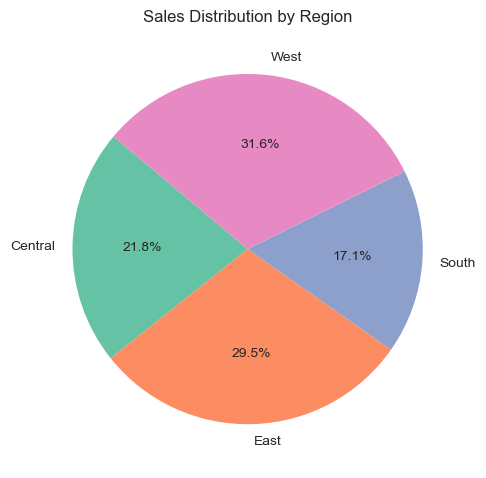

In [26]:
region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(5, 5))
region_sales.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set2'))
plt.title("Sales Distribution by Region")
plt.ylabel("")
plt.tight_layout()
plt.savefig("regional_sales_pie.png")  # Save for PPT
plt.show()

#### **5.Sub-Category Profitability (Horizontal Bar Chart)**

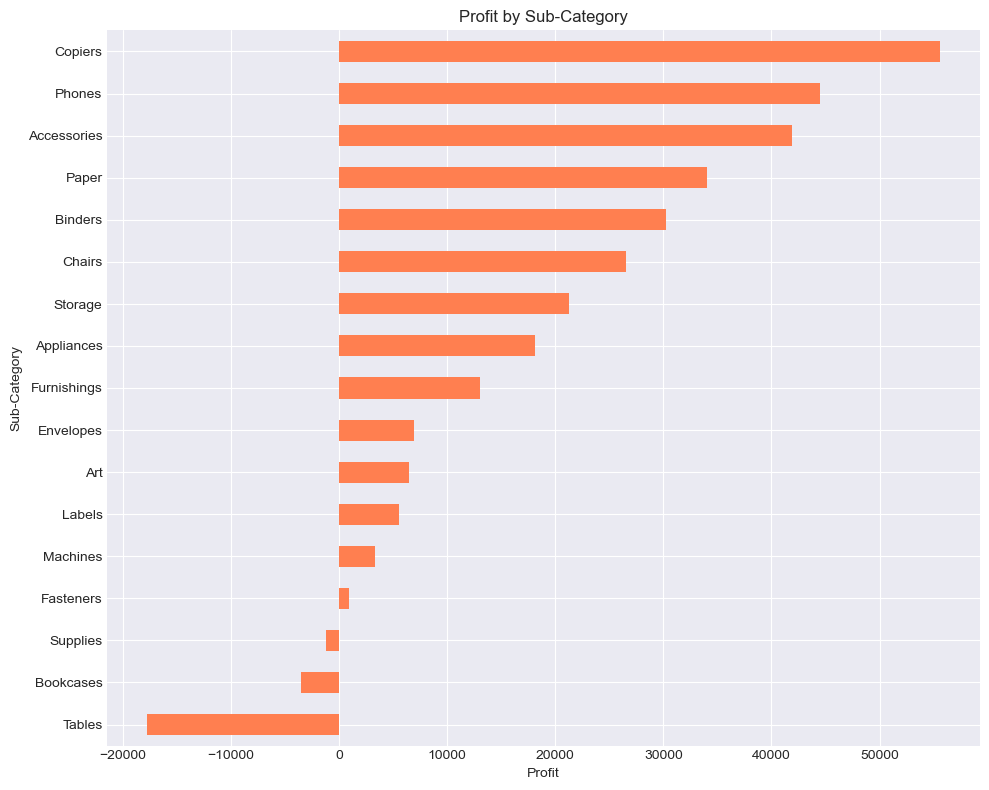

In [27]:
subcat_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values()

plt.figure(figsize=(10, 8))
subcat_profit.plot(kind='barh', color='coral')
plt.title("Profit by Sub-Category")
plt.xlabel("Profit")
plt.tight_layout()
plt.savefig("subcat_profit.png")
plt.show()

#### **6.Sales by Customer Segment (Bar Chart)**

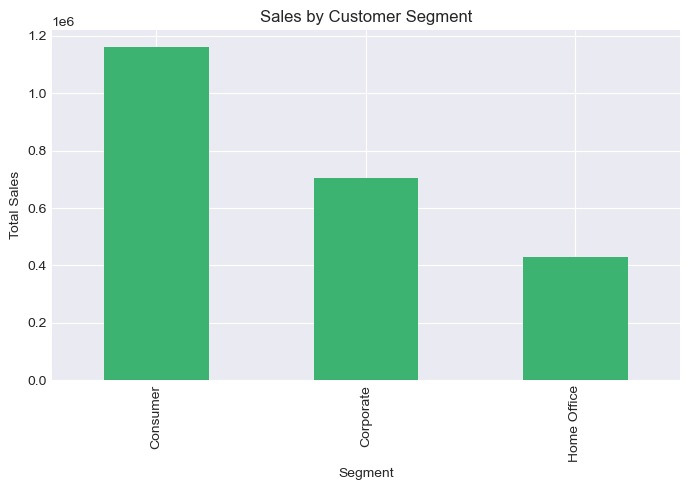

In [28]:
segment_sales = df.groupby("Segment")["Sales"].sum()

plt.figure(figsize=(7, 5))
segment_sales.plot(kind='bar', color='mediumseagreen')
plt.title("Sales by Customer Segment")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.savefig("segment_sales.png")
plt.show()

### **Key insights:**

1.**The top-selling product** is the Canon ImageCLASS 2200 Advanced Copier, contributing the highest revenue among all products sold.

2.**Sean Miller** is identified as the most valuable customer, generating the highest total sales for the business.

3.The month with the **highest sales volume** is **November 2017**, likely due to seasonal promotions or end-of-year purchases.

4.Among all regions, the **Western region** recorded the **highest total sales**, indicating strong market performance in that area.

5.**California** typically dominates sales across all categories, especially **Technology** is the **best-performing product category**, consistently delivering the highest sales figures across regions.

## **How can the company improve sales performance and customer satisfaction by analyzing sales data?**

#### 1.Optimize High-Performing Products
By identifying top-selling products like the Canon ImageCLASS 2200 Copier, the company can:

- Prioritize inventory for high-demand items

- Offer bundles or premium versions

- Target marketing efforts to promote these products further

This ensures product availability and boosts customer satisfaction through reliable stock.

#### 2.Engage High-Value Customers
Top customers like Sean Miller drive a significant portion of revenue. The company can:

- Create customer segments based on sales volume

- Offer loyalty programs, exclusive discounts, or early product access

- Use personalized communication to retain and reward loyal clients

Happy, recognized customers are more likely to return and recommend the brand.

#### 3.Leverage Seasonal Trends
Sales peak in months like November, likely due to holiday and year-end corporate purchases. To take advantage:

- Launch seasonal promotions (e.g., Black Friday, Diwali offers)

- Increase marketing budgets and inventory planning during peak months

- Offer time-limited discounts to create urgency and drive volume

This captures demand spikes while enhancing the customer shopping experience.

#### 4.Expand in High-Performing Regions
The Western region shows higher performance, suggesting a favorable market. The company should:

- Investigate what’s driving success there (e.g., urbanization, sales reps)

- Replicate successful strategies in other regions

- Expand delivery, warehousing, and local partnerships in high-demand areas

Tailored regional strategies help ensure better service and regional satisfaction.

#### 5.Focus on High-Profit Categories
The Technology category outperforms others in both sales and profit. The company can:

- Increase product variety within this category

- Offer financing or support services for higher-end tech products

- Collaborate with tech brands for exclusive deals

Meeting the market’s appetite for technology enhances value delivery to customers.